In [1]:
class Constants():
    def __init__(self):
        self.msun = 1.989e33
        self.rsun = 6.955e10
        self.G  = 6.674e-8
        self.yr = 3.1536e7
        self.h  = 6.6260755e-27
        self.kB = 1.380658e-16
        self.mp = 1.6726219e-24
        self.me = 9.10938356e-28
        self.c  = 2.99792458e10
        self.pc = 3.085677581e18
        self.au = 1.496e13
        self.q = 4.8032068e-10
        self.eV = 1.6021772e-12
        self.sigmaSB = 5.67051e-5
        self.sigmaT = 6.6524e-25
        self.Rg = 8.3145e7
        
        print("Constants defined...")
        return None

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import ascii
from astropy.table import Table
import athena_read as ar
from glob import glob
import planet_wind_utils as pw
import seaborn as sns
c = Constants()
import mesh_tools as mt
import plotly.graph_objects as go 

%matplotlib inline

# set some global options
plt.rcParams['figure.figsize'] = (6,5)
plt.rcParams['legend.frameon'] = False
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.borderpad'] = 0.2
plt.rcParams['legend.labelspacing'] = 0.2
plt.rcParams['legend.handletextpad'] = 0.2
plt.rcParams['font.family'] = 'stixgeneral'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 16


import importlib.metadata
import pkg_resources
import sys

def print_package_version(package_name):
    try:
        version = pkg_resources.get_distribution(package_name).version
        print(f"{package_name} version: {version}")
    except pkg_resources.DistributionNotFound:
        print(f"Package '{package_name}' not found.")
    

print("Python:", sys.version)
print_package_version("numpy")
print_package_version("matplotlib")
print_package_version("astropy")
print_package_version("plotly")

Constants defined...
Python: 3.8.3 (default, Jul  2 2020, 11:26:31) 
[Clang 10.0.0 ]
numpy version: 1.22.1
matplotlib version: 3.7.2
astropy version: 5.1.1
plotly version: 5.5.0


<ipython-input-1-f3856fce7e5b>:50: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [2]:
## Directory 
DATAPATH = "./planet_wind_w12/c/"

## input file 
!head {DATAPATH + "athinput.w12"}

rp = 1.405e10 
rs = 1.175e11 

# rescale parameter
SCALE = 1

<job>
problem_id = PW_W12     	# problem ID: basename of output filenames

<output1>
file_type  = hdf5        # Binary data dump
variable   = prim        # variables to be output
dt         = 94256.0  #94298.7     # time increment between outputs 1e5
xdmf = 0

<output2>


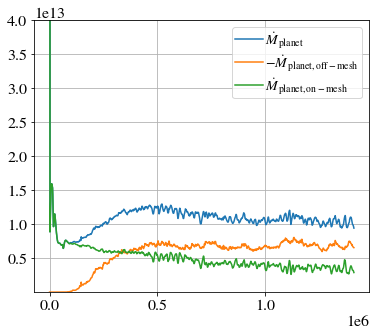

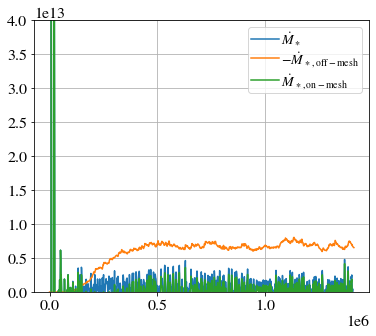

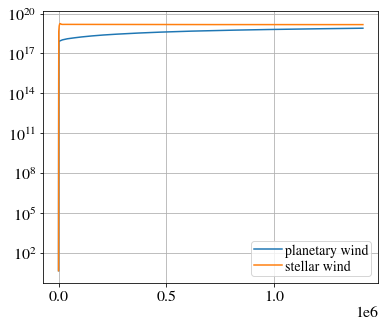

log10 mdot Planet =  13.022487149615673
log10 mdot Sstar =  11.766958899476036


In [3]:
## Check for steady state

hst = ascii.read(DATAPATH+"PW_W12.hst",
          names=["time","dt","mass","1-mom","2-mom","3-mom","1-KE","2-KE","3-KE","tot-E","0-scalar","1-scalar","md_m_p","md_m_s"] )

hst['MdotP'] = np.gradient(hst['0-scalar'])/np.gradient(hst['time'])-hst['md_m_p']
plt.plot(hst['time'],hst['MdotP'] ,label=r'$\dot M_{\rm planet}$')
plt.plot(hst['time'],-hst['md_m_p'],label=r'$-\dot M_{\rm planet,off-mesh}$')
plt.plot(hst['time'],np.gradient(hst['0-scalar'])/np.gradient(hst['time']),label=r'$\dot M_{\rm planet,on-mesh}$')
#plt.yscale('log')
plt.ylim(1e10,4e13)


plt.legend(frameon=True)
plt.grid()
plt.show()


hst['MdotS'] = np.gradient(hst['1-scalar'])/np.gradient(hst['time'])-hst['md_m_s']
plt.plot(hst['time'],hst['MdotS'] ,label=r'$\dot M_{\ast}$')
plt.plot(hst['time'],-hst['md_m_p'],label=r'$-\dot M_{\rm \ast,off-mesh}$')
plt.plot(hst['time'],np.gradient(hst['1-scalar'])/np.gradient(hst['time']),label=r'$\dot M_{\rm \ast,on-mesh}$')
plt.ylim(0,4e13)
#plt.semilogy()
plt.legend(frameon=True)
plt.grid()
plt.show()


plt.plot(hst['time'],hst['0-scalar'],label='planetary wind')
plt.plot(hst['time'],hst['1-scalar'],label='stellar wind')
plt.semilogy()
plt.legend(frameon=True)
plt.grid()
plt.show()

print("log10 mdot Planet = ",np.log10(np.median(hst[hst['time']>1e6]['MdotP'])))
print("log10 mdot Sstar = ",np.log10(np.median(hst[hst['time']>1e6]['MdotS'])))

In [4]:
from astropy.convolution import convolve, Box1DKernel

def get_sigmab(d,sep,rp,nanthresh=1e-13,x1_min_los=7e10):
    b = (d['x3v']-np.pi)*sep
    sigma = np.nansum(np.where(d['gx1v']>x1_min_los,d['r0']*d['rho']*d['gdr'],np.nan),axis=2)[:,0]
    sigma=np.where(sigma>nanthresh,sigma,np.nan)
    #sigma=np.where(np.abs(b)>rp,sigma,0)
    velr = np.nansum(np.where(d['gx1v']>x1_min_los,d['r0']*d['rho']*d['gdr']*-d['vel1'],np.nan),axis=2)[:,0]/sigma
    #velr = (np.sum(-d['vel1']*np.exp(-d['r0']*d['rho']*d['gdr']),axis=2)/np.sum(np.exp(-d['r0']*d['rho']*d['gdr']),axis=2))[:,0]
    sel = np.abs(b)>rp
    return b[sel],sigma[sel],velr[sel]


def read_get_sigmab(base_dir,fn,level,x1_min,x1_max,x3range=np.pi,nanthresh=1.e-13,
                   makeplot=True,x1_min_los=7e10):
    """ read file from directory and compute column values """
    orb = pw.read_trackfile(base_dir+"pm_trackfile.dat")
    x2sliceval = pw.get_midplane_theta(base_dir+fn,level=level)
    sep = orb['sep'][0]

    d = pw.read_data(base_dir+fn,orb,
                     level=level,
                     get_cartesian=True,
                     x2_min=x2sliceval,x2_max=x2sliceval,
                     x1_min = x1_min, 
                     x1_max = x1_max,
                     x3_min = np.pi - x3range,
                     x3_max = np.pi + x3range,
                     gamma=1.0001)
    d1 = d['x1f'][1:] - d['x1f'][:-1]
    d['gdr']=np.broadcast_to(d1,(len(d['x3v']),len(d['x2v']),len(d['x1v'])) )
    
    b,sigma,velr  = get_sigmab(d,sep,rp,nanthresh=nanthresh,x1_min_los=x1_min_los)
  
    return d,sep,b,sigma,velr


def sliceplot(d,sep):
    
    plt.figure(figsize=(5,4) )
    plt.pcolormesh(d['x'][:,0,:]/c.au,
                   d['y'][:,0,:]/c.au,
                   np.log10(d['rho'])[:,0,:] ,
                   cmap=plt.cm.Blues,vmax=-16,vmin=-22)
    plt.colorbar(label=r"$\log_{10} \left( \rho \right)$",extend='both')

    plt.axis('equal')

    lim = sep*2
    plt.xlim(-lim/c.au,lim/c.au)
    plt.ylim(-lim/c.au,lim/c.au)
    plt.xlabel('$x$ [au]')
    plt.ylabel('$y$ [au]')
    #plt.show()
    
    
    
def lineplot(sep,b,sigma,vr):
    db = b[1]-b[0]
    width = 2*rs/db
    sigmac = convolve(sigma,Box1DKernel(width),nan_treatment='fill',fill_value=np.nan)
    vrc = convolve(vr,Box1DKernel(width) ,nan_treatment='fill',fill_value=np.nan)


    plim=rs/sep/(2*np.pi)*5

    plt.figure()
    plt.subplot(211)
    plt.semilogy(-b/sep/(2*np.pi),sigma,'-',lw=2,color='k')
    plt.semilogy(-b/sep/(2*np.pi),sigmac,'--',lw=2,color='r')
    plt.xlim(-plim,plim)
    plt.xticks(visible=False)
    plt.axvline(0,zorder=0,color='grey')
    plt.axvline(-rs/sep/(2*np.pi),zorder=0,color='grey',ls=':')
    plt.axvline(rs/sep/(2*np.pi),zorder=0,color='grey',ls=':')
    plt.ylabel(r"$\Sigma$ [g cm$^{-2}$]")

    plt.subplot(212)
    plt.plot(-b/sep/(2*np.pi),vr/1e5,'-',lw=2,color='k')
    plt.plot(-b/sep/(2*np.pi),vrc/1e5,'--',lw=2,color='r')
    plt.plot(-b/sep/(2*np.pi),np.sin(-b/sep) * np.sqrt( c.G*c.msun/sep ) / 1.e5,zorder=0,label='planet frame' )
    plt.xlim(-plim,plim) 
    plt.axhline(0,ls='--',color='grey',zorder=0)
    plt.axvline(0,zorder=0,color='grey')
    plt.axvline(-rs/sep/(2*np.pi),zorder=0,color='grey',ls=':')
    plt.axvline(rs/sep/(2*np.pi),zorder=0,color='grey',ls=':')
    plt.ylim(-30,30)
    plt.ylabel(r"$v_{\rm los}$ [km s$^{-1}$]")
    plt.xlabel('phase')
    
    plt.subplots_adjust(hspace=0)
    #plt.show()    

def makefig(d,sep,b,sigma,vr):
    myshade = 'gouraud'

    vmin=-20
    vmax=-14
    PorbHR = 1.0914*24
    
    fig = plt.figure(figsize=(5.5,8))
    f1,f2 = fig.subfigures(nrows=2,ncols=1,height_ratios=[1.5,1])
    ax = f1.subplots()

    lim = sep*2
    im = plt.pcolormesh(pw.get_plot_array_midplane(d['x'][:,0,:])/c.au,
               pw.get_plot_array_midplane(d['y'][:,0,:])/c.au,
               pw.get_plot_array_midplane(np.log10(d['rho'][:,0,:]*SCALE)),
               cmap='magma',vmin=vmin,vmax=vmax,shading=myshade,rasterized=True)

    ax.set_aspect('equal')
    ax.set_xlim(-lim/c.au,lim/c.au)
    ax.set_ylim(-lim/c.au,lim/c.au)


    axins = ax.inset_axes([0.53, 0.53, 0.45, 0.45])
    axins.pcolormesh(pw.get_plot_array_midplane(d['x'][:,0,:])/c.au,
                 pw.get_plot_array_midplane(d['y'][:,0,:])/c.au,
                 pw.get_plot_array_midplane(np.log10(d['rho'][:,0,:]*SCALE)),
                 cmap='magma',vmin=vmin,vmax=vmax,shading=myshade,rasterized=True)

    # sub region of the original image
    ilim = 8*rp
    axins.set_aspect('equal')
    axins.set_xlim((-ilim-sep)/c.au, (ilim-sep)/c.au)
    axins.set_ylim(-ilim/c.au, ilim/c.au)
    axins.set_xticklabels('')
    axins.set_yticklabels('')
    axins.set_xticks([])
    axins.set_yticks([])
    #plt.xticks(visible=False)
    #plt.yticks(visible=False)
    ax.indicate_inset_zoom(axins)


    #ax.annotate(labellist[i],(0.05,0.9),xycoords='axes fraction',color='w')
    ax.set_xlabel(r'$x \ \ [\rm {au}]$')
    ax.set_ylabel(r'$y \ \ [\rm {au}]$')


    fig.subplots_adjust(wspace=0.0,right=0.95)
    #cax = fig.add_axes([0.96, 0.21, 0.01, 0.6])
    cb=fig.colorbar(im,label=r'$\log_{10}\left(\rho \right) \ \ [{\rm g \ cm}^{-3}]$',extend='both')
    cb.solids.set_edgecolor("face")




    db = b[1]-b[0]
    width = 2*rs/db
    sigmac = convolve(sigma,Box1DKernel(width),nan_treatment='fill',fill_value=np.nan)
    vrc = convolve(vr,Box1DKernel(width) ,nan_treatment='fill',fill_value=np.nan)


    plim=rs/sep/(2*np.pi)*3*PorbHR
    

    a1,a2 = f2.subplots(2,1)
    #a1.semilogy(-b/sep/(2*np.pi)*PorbHR,sigma,'-',lw=2,color='k')
    a1.semilogy(-b/sep/(2*np.pi)*PorbHR,SCALE*sigmac,'-',lw=2,color='k')
    a1.set_xlim(-plim,plim)
    #a1.set_xticks(visible=False)
    a1.axvline(0,zorder=0,color='grey')
    a1.axvline(-rs/sep/(2*np.pi)*PorbHR,zorder=0,color='grey',ls=':')
    a1.axvline(rs/sep/(2*np.pi)*PorbHR,zorder=0,color='grey',ls=':')
    a1.set_ylabel(r"$\Sigma$ [g cm$^{-2}$]")


    #a2.plot(-b/sep/(2*np.pi)*PorbHR,vr/1e5,'-',lw=2,color='k')
    a2.plot(-b/sep/(2*np.pi)*PorbHR,vrc/1e5,'-',lw=2,color='k')
    a2.plot(-b/sep/(2*np.pi)*PorbHR,np.sin(-b/sep) * np.sqrt( c.G*c.msun/sep ) / 1.e5,zorder=0,label='planet frame' )
    a2.set_xlim(-plim,plim) 
    a2.axhline(0,ls='--',color='grey',zorder=0)
    a2.axvline(0,zorder=0,color='grey')
    a2.axvline(-rs/sep/(2*np.pi)*PorbHR,zorder=0,color='grey',ls=':')
    a2.axvline(rs/sep/(2*np.pi)*PorbHR,zorder=0,color='grey',ls=':')
    a2.set_ylim(-50,50)
    a2.set_ylabel(r"$\bar v_{\rm los}$ [km s$^{-1}$]")
    a2.set_xlabel('time [hr]')

    f2.subplots_adjust(hspace=0,right=0.8)
    

reading orbit file for planet wind simulation...
read_data...reading file ./planet_wind_w12/c/PW_W12.out1.00015.athdf
 ...file read, constructing arrays
 ...gamma= 1.0001
...getting cartesian arrays...


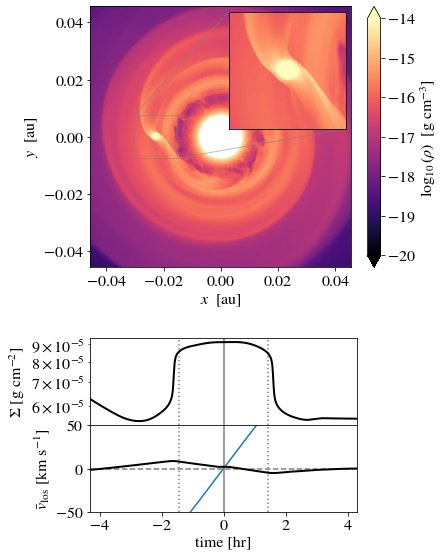

In [5]:
d,sep,b,sigma,vr = read_get_sigmab(base_dir=DATAPATH,
                             fn="PW_W12.out1.00015.athdf",
                             level=3,
                             x1_min=1.175e10,
                             x1_min_los=1.175e10,
                             x1_max=0.1*c.au*2,
                             x3range = np.pi, #np.pi/2.5,
                             nanthresh=1e-11)


makefig(d,sep,b,sigma,vr)
plt.savefig("figures/sim_slice_los.pdf",bbox_inches='tight')

In [6]:
# Try making a 3D figure 

In [7]:
def makesphere(x, y, z, radius, resolution=10):
    """Return the coordinates for plotting a sphere centered at (x,y,z)"""
    u, v = np.mgrid[0:2*np.pi:resolution*2j, 0:np.pi:resolution*1j]
    X = radius * np.cos(u)*np.sin(v) + x
    Y = radius * np.sin(u)*np.sin(v) + y
    Z = radius * np.cos(v) + z
    return (X, Y, Z)

    
def make_3d_plot(base_dir,fn, filename_out,nxyz=200,mylevel=1,sep=0.025,mylev=[-16.5,-17,-17.5],rp=7e9,rs=7e10):
    orb = pw.read_trackfile(base_dir+"pm_trackfile.dat")
    print( "ORB: ... ", orb.colnames)

    myfile = base_dir+fn

    # NOTE: read @level=None to get full resolution. 
    d = pw.read_data(myfile,orb,
                     level=mylevel,
                     get_cartesian=True,
                     x1_min = 7e10, x1_max = sep*4.5*c.au
                    )

    t= d['Time']
    rcom,vcom = pw.rcom_vcom(orb,t)
    x2,y2,z2 = pw.pos_secondary(orb,t)
    
    d['rho0'] = np.where( d['r0']>0.5, d['rho']*d['r0'], 0.0)
    
    # define a uniform mesh 
    #nxyz = 200
    lim = 3*sep*c.au
    xx,yy,zz,r,th,ph = mt.get_uniform_meshgrid(lim,npoints=nxyz,center=[0,0,0])

    # define interpolating functions & get data
    rho0_interp = mt.get_interp_function(d,"rho0")
    rho0_vals = rho0_interp((ph,th,r))

    # get a surface mesh object 
    verts1,faces1, centroids1, areas1, normals1 = mt.get_marching_cubes_mesh(xx,yy,zz,np.log10(rho0_vals),mylev[0],step_size=1)
    verts2,faces2, centroids2, areas2, normals2 = mt.get_marching_cubes_mesh(xx,yy,zz,np.log10(rho0_vals),mylev[1],step_size=1)
    verts3,faces3, centroids3, areas3, normals3 = mt.get_marching_cubes_mesh(xx,yy,zz,np.log10(rho0_vals),mylev[2],step_size=1)

    # Observer vector
    zf = 2.15
    n0 = np.array([-1,0,0.45])
    n0 = n0/np.linalg.norm(n0)
    camera = dict(
        eye=dict(x=n0[0]*zf, y=n0[1]*zf, z=n0[2]*zf)
    )
    #layout = go.Layout(scene=dict(aspectmode='data',camera=camera))
    myrange=np.array([-2*sep,2*sep])
    myticks = [-sep,0,sep]
    layout=go.Layout(scene = dict(xaxis = dict(range=myrange,showgrid=True,showbackground=False,title='x [au]',tickvals=myticks,gridcolor='grey'),
                                  yaxis = dict(range=myrange,showgrid=True,showbackground=False,title='y [au]',tickvals=myticks,gridcolor='grey'),
                                  zaxis = dict(range=myrange,showgrid=True,showbackground=False,title='z [au]',tickvals=myticks,gridcolor='grey'),
                                  #aspectmode='data',
                                  camera=camera),
                    margin=dict(r=0, l=0, b=0, t=0) )
    layout_noax = go.Layout(scene = dict(xaxis = dict(range=myrange,showgrid=False,showbackground=False,title='',tickvals=[],gridcolor='white'),
                                         yaxis = dict(range=myrange,showgrid=False,showbackground=False,title='',tickvals=[],gridcolor='white'),
                                         zaxis = dict(range=myrange,showgrid=False,showbackground=False,title='',tickvals=[],gridcolor='white'),
                                  #aspectmode='data',
                                  camera=camera),
                    margin=dict(r=0, l=0, b=0, t=0) )
    layout_noax2 = go.Layout(scene = dict(xaxis = dict(showgrid=False,showbackground=False,title='',tickvals=[],gridcolor='white'),
                                         yaxis = dict(showgrid=False,showbackground=False,title='',tickvals=[],gridcolor='white'),
                                         zaxis = dict(showgrid=False,showbackground=False,title='',tickvals=[],gridcolor='white'),
                                  aspectmode='data',
                                  camera=camera),
                    margin=dict(r=0, l=0, b=0, t=0) )

    # planet
    xp,yp,zp=makesphere(x2/c.au,y2/c.au,z2/c.au,rp/c.au,resolution=30)
    xs,ys,zs=makesphere(0,0,0,rs/c.au,resolution=30)

    mycm = 'plasma'


    fig = go.Figure(
        data=[
                go.Mesh3d(
                    x=verts1[:,0]/c.au,
                    y=verts1[:,1]/c.au,
                    z=verts1[:,2]/c.au,
                    i=faces1[:,0],
                    j=faces1[:,1],
                    k=faces1[:,2],
                    intensity=np.ones_like(verts1[:,0])*0.1,
                    cmin=0,cmax=1,colorscale=mycm,
                    opacity=0.6,
                    #lighting=dict(ambient=1),
                    #lightposition=dict(x=0,y=0,z=0),
                    visible=True,showscale=False
                     ),
                  go.Mesh3d(
                    x=verts2[:,0]/c.au,
                    y=verts2[:,1]/c.au,
                    z=verts2[:,2]/c.au,
                    i=faces2[:,0],
                    j=faces2[:,1],
                    k=faces2[:,2],
                    intensity=np.ones_like(verts2[:,0])*0.5,
                    cmin=0,cmax=1,colorscale=mycm,
                    opacity=0.25,
                    #lighting=dict(ambient=1),
                    #lightposition=dict(x=0,y=0,z=0),
                    visible=True,showscale=False
                     ),
                  go.Mesh3d(
                    x=verts3[:,0]/c.au,
                    y=verts3[:,1]/c.au,
                    z=verts3[:,2]/c.au,
                    i=faces3[:,0],
                    j=faces3[:,1],
                    k=faces3[:,2],
                    intensity=np.ones_like(verts3[:,0])*0.9,
                    cmin=0,cmax=1,colorscale=mycm,
                    opacity=0.1,
                    #lighting=dict(ambient=1),
                    #lightposition=dict(x=0,y=0,z=0),
                    visible=True,showscale=False
                     ),

                 go.Surface(x=xp,y=yp,z=zp,
                              showscale=False,
                              surfacecolor=np.zeros_like(zp),
                              colorscale='Reds',
                              lighting=dict(ambient=1)),
                 go.Surface(x=xs,y=ys,z=zs,
                              showscale=False,
                              surfacecolor=np.zeros_like(zs),
                              colorscale='Reds',
                              lighting=dict(ambient=1)),
             ],
        
          layout=layout_noax2) #go.Layout(scene=dict(aspectmode='data')) ) #layout=layout)

    #fig.show()
    fig.write_image(filename_out)
    
    

In [8]:
make_3d_plot(DATAPATH,"PW_W12.out1.00015.athdf",'figures/3d_view.pdf',
                 nxyz=300,mylevel=2,sep=0.025,mylev=[-14.5,-15.5,-16.5],rp=rp,rs=rs)

reading orbit file for planet wind simulation...
ORB: ...  ['ncycle', 'time', 'dt', 'm1', 'm2', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'sep', 'r', 'rhat', 'v', 'vmag', 'vhat', 'xcom', 'ycom', 'zcom', 'vxcom', 'vycom', 'vzcom', 'rcom', 'vcom']
read_data...reading file ./planet_wind_w12/c/PW_W12.out1.00015.athdf
 ...file read, constructing arrays
 ...gamma= 1.6666666666666667
...getting cartesian arrays...


<ipython-input-7-c63a26b5439c>:39: RuntimeWarning: divide by zero encountered in log10
  verts1,faces1, centroids1, areas1, normals1 = mt.get_marching_cubes_mesh(xx,yy,zz,np.log10(rho0_vals),mylev[0],step_size=1)
<ipython-input-7-c63a26b5439c>:40: RuntimeWarning: divide by zero encountered in log10
  verts2,faces2, centroids2, areas2, normals2 = mt.get_marching_cubes_mesh(xx,yy,zz,np.log10(rho0_vals),mylev[1],step_size=1)
/Users/morganmacleod/Dropbox/PlanetWind/Analysis/WASP-12b/WASP12_SV_Paper_2026/mesh_tools.py:201: RuntimeWarning: invalid value encountered in true_divide
  norms = (cp.T/np.linalg.norm(cp,axis=1)).T
/Users/morganmacleod/Dropbox/PlanetWind/Analysis/WASP-12b/WASP12_SV_Paper_2026/mesh_tools.py:203: RuntimeWarning: invalid value encountered in true_divide
  return (cp.T/np.linalg.norm(cp,axis=1)).T
<ipython-input-7-c63a26b5439c>:41: RuntimeWarning: divide by zero encountered in log10
  verts3,faces3, centroids3, areas3, normals3 = mt.get_marching_cubes_mesh(xx,yy,zz,np.l